In [1]:
from pathlib import Path

import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

In [4]:
QUANTITY = "forces"

In [5]:
# ROOTNAMES = [
#     "nonperiodic-exact",
#     "nonperiodic-msm_rcut-3.0_p-4",
#     "nonperiodic-msm_rcut-6.0_p-6",
# ]

In [22]:
# TODO: name something other than "rootname"? (de facto, what it is is the
#  algorithm/algorithm settings?)
ROOTNAMES_TO_LABELS = {
    "msm_rcut-3.0_p-4": "$r_{\mathrm{cut}} = 3 \overline{d}$, $p=4$",
    "msm_rcut-6.0_p-6": "$r_{\mathrm{cut}} = 6 \overline{d}$, $p=6$",
    "exact": "exact",
}

In [23]:
# MARKERLIST = ["o", "s", "d"]
# # plt.rcParams["font.size"] = 14    # TODO
#
# # TODO: loop over this (also do "periodic")
# PBCLABEL = "nonperiodic"
#
# fig, ax = plt.subplots()
# ax.set_xlabel("Number of particles")
# ax.set_ylabel("Time / ms")
# for rootname, marker in zip(ROOTNAMES_TO_LABELS, MARKERLIST):
#     resultsdirname = PBCLABEL + "-" + rootname
#     label = ROOTNAMES_TO_LABELS[rootname]
#     for double_precision, linestyle, facecolor in zip(
#         [False, True], ["--", "-"], ["none", None]
#     ):
#         color = None
#         if double_precision:
#             resultsdirname += "_doubleprec"
#             label += ", double prec."
#             color = lns[0].get_color()
#         resultsdir = BASERESULTSDIR / resultsdirname
#         results = pd.read_csv(resultsdir / "results.csv")
#         particle_numbers = results["n_particles"].values
#         times = results["time"].values
#         lns = ax.plot(
#             particle_numbers,
#             1e3 * times,
#             label=label,
#             alpha=0.6,
#             color=color,
#             marker=marker,
#             markerfacecolor=facecolor,
#             linestyle=linestyle,
#         )
#
# ax.legend(reverse=True)
#
# ax.set_xscale("log")
# ax.set_yscale("log")
# fig.tight_layout()
# filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}" + "_loglog"
# for suffix in [".png", ".pdf"]:
#     fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))
#
# ax.set_xscale("linear")
# ax.set_yscale("linear")
# fig.tight_layout()
# ax.set_xlim(left=0.0)
# ax.set_ylim(bottom=0.0)
# filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}"
# for suffix in [".png", ".pdf"]:
#     fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

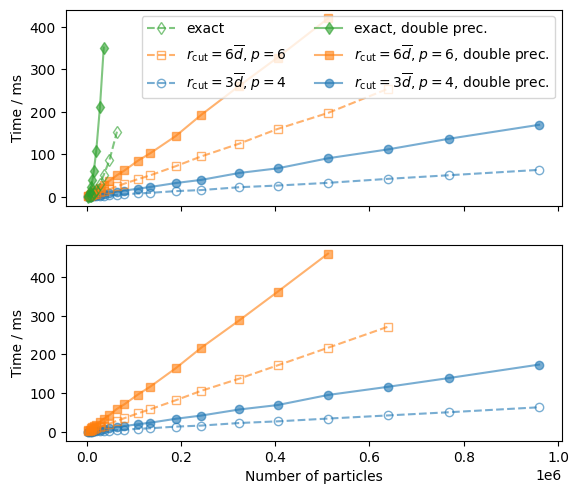

In [36]:
MARKERLIST = ["o", "s", "d"]
# plt.rcParams["font.size"] = 14    # TODO

fig, axs = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(6.4, 5.6),
)
axs[-1].set_xlabel("Number of particles")
for ax, pbclabel in zip(axs, ["nonperiodic", "periodic"]):
    ax.set_ylabel("Time / ms")
    for rootname, marker in zip(ROOTNAMES_TO_LABELS, MARKERLIST):
        if pbclabel == "periodic" and rootname == "exact":
            # Cannot compute an exact all-pairs reference result in periodic case
            continue
        resultsdirname = pbclabel + "-" + rootname
        label = ROOTNAMES_TO_LABELS[rootname]
        for double_precision, linestyle, facecolor in zip(
            [False, True], ["--", "-"], ["none", None]
        ):
            color = None
            if double_precision:
                resultsdirname += "_doubleprec"
                label += ", double prec."
                color = lns[0].get_color()
            resultsdir = BASERESULTSDIR / resultsdirname
            results = pd.read_csv(resultsdir / "results.csv")
            particle_numbers = results["n_particles"].values
            times = results["time"].values
            lns = ax.plot(
                particle_numbers,
                1e3 * times,
                label=label,
                alpha=0.6,
                color=color,
                marker=marker,
                markerfacecolor=facecolor,
                linestyle=linestyle,
            )

reordered_lines = axs[0].get_lines()[1::2] + axs[0].get_lines()[::2]
axs[0].legend(handles=reordered_lines, ncols=2, reverse=True)

plt.show()

# TODO: title the subplots with periodic/nonperiodic?

# ax.set_xscale("log")
# ax.set_yscale("log")
# fig.tight_layout()
# filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}" + "_loglog"
# for suffix in [".png", ".pdf"]:
#     fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))
#
# ax.set_xscale("linear")
# ax.set_yscale("linear")
# fig.tight_layout()
# ax.set_xlim(left=0.0)
# ax.set_ylim(bottom=0.0)
# filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}"
# for suffix in [".png", ".pdf"]:
#     fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))